# Lab 09: MLB Swing Probability Modeling

---
author: Trishla Nair
date: April 8, 2024
embed-resources: true
---

## Introduction

In this report I attempt to develop a well calibrated probability model that estimates the probability of inducing a batter to swing given the characteristics of a pitch thrown, in addition to other information such as game situation, for a particular pitcher

## Methods

In [70]:
# imports
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from joblib import parallel_backend
from joblib import dump
#from sklearn.linear_model import LogisticRegression
#from sklearn.linear_model import Lasso
#from sklearn.linear_model import Ridge
#from sklearn.ensemble import HistGradientBoostingClassifier
#from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV

### Data

In [71]:
# load data
pitches_train = pd.read_csv(
    "https://cs307.org/lab-09/data/pitches-train.csv",
)
pitches_test = pd.read_csv(
    "https://cs307.org/lab-09/data/pitches-test.csv",
)

The aqcuired data is already split into training and testing data. The training data has 21 features and 2653 observations. When we explore the swing rate per pitch type, they all can approximate to 0.5, with the Cutter having the lowest swing rate at around 0.45 and the Changeup with the most at 0.53.

In [72]:
# summary statistics
pitches_train

,pitch_name,release_extension,release_pos_x,release_pos_y,release_pos_z,release_speed,release_spin_rate,spin_axis,plate_x,plate_z,...,balls,strikes,on_3b,on_2b,on_1b,outs_when_up,stand,sz_top,sz_bot,swing
0,Cutter,6.6,-2.76,53.86,5.81,92.6,2376.0,195.0,-0.09,2.79,...,3,1,0,0,0,1,L,3.15,1.52,1
1,Changeup,6.8,-2.87,53.74,5.66,86.3,1511.0,226.0,-1.47,1.84,...,2,1,0,0,0,1,L,3.13,1.56,0
2,Changeup,6.7,-2.83,53.82,5.68,87.9,1570.0,224.0,-1.52,2.38,...,1,1,0,0,0,1,L,3.12,1.51,0
3,Knuckle Curve,6.7,-2.70,53.78,5.78,82.4,2398.0,32.0,0.20,1.04,...,1,0,0,0,0,1,L,3.15,1.52,1
4,Cutter,6.7,-2.64,53.83,5.81,91.0,2427.0,189.0,0.89,1.65,...,0,0,0,0,0,1,L,3.12,1.51,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2648,4-Seam Fastball,6.8,-2.64,53.75,5.99,93.4,2411.0,206.0,0.59,2.91,...,0,0,0,0,0,1,L,3.50,1.81,0
2649,Slider,6.3,-2.91,54.19,5.86,87.3,2541.0,113.0,1.38,1.73,...,1,2,0,0,0,0,R,3.19,1.48,1
2650,Knuckle Curve,6.4,-2.91,54.13,5.87,84.7,2539.0,35.0,0.81,0.11,...,1,1,0,0,0,0,R,3.19,1.48,1
2651,4-Seam Fastball,6.4,-2.67,54.13,6.04,94.3,2531.0,201.0,1.05,1.79,...,0,1,0,0,0,0,R,3.03,1.48,0


In [73]:
swing_rate_by_pitch_type = pitches_train.groupby('pitch_name')['swing'].mean()
overall_swing_rate = pitches_train['swing'].mean()
print(swing_rate_by_pitch_type)
print("Overall Swing Rate:", overall_swing_rate)

pitch_name
4-Seam Fastball    0.471451
Changeup           0.536313
Cutter             0.453782
Knuckle Curve      0.462875
Slider             0.492188
Name: swing, dtype: float64
Overall Swing Rate: 0.47757255936675463


<Axes: xlabel='pitch_name'>

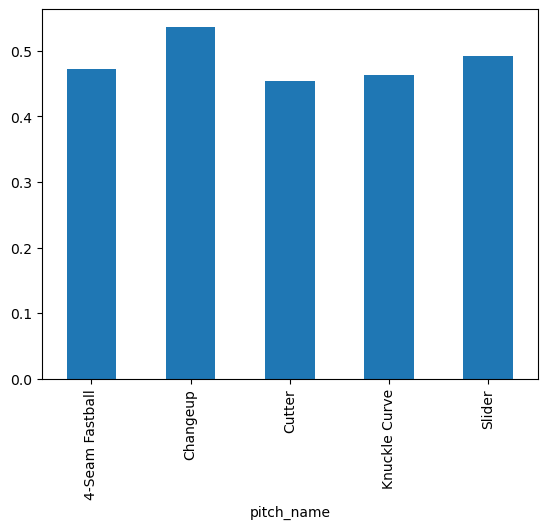

In [83]:
# visualizations
swing_rate_by_pitch_type.plot.bar()

This plot visualises the average swing rate per pitch.

### Models

In [75]:
# process data for ML
# create X and y for train data
X_train = pitches_train.drop(columns=["swing"])
y_train = pitches_train["swing"]

# create X and y for test data
X_test = pitches_test.drop(columns=["swing"])
y_test = pitches_test["swing"]

In [78]:
# train models
numeric_features = [
    "release_extension", "release_pos_x", "release_pos_y", "release_pos_z", 
    "release_speed", "release_spin_rate", "spin_axis", "plate_x", "plate_z", 
    "pfx_x", "pfx_z", "balls", "strikes", "on_3b", "on_2b", "on_1b", 
    "outs_when_up", "sz_top", "sz_bot"
]
categorical_features = [
    "pitch_name", "stand"
]

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

# Define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")), 
           ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,    # Number of boosting rounds
    learning_rate=0.5,   # Reduce learning rate if needed
    random_state=42
)
m = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", adaboost_model)
])
param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__learning_rate": [0.1, 0.5, 1.0],
    "classifier__estimator__max_depth": [1, 2, 3]
}

grid_search = GridSearchCV(m, param_grid, cv=5, scoring="accuracy", verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")

calibrated_model = CalibratedClassifierCV(best_pipeline, method="isotonic", cv="prefit")
mod = calibrated_model.fit(X_train, y_train)
y_prob_test = calibrated_model.predict_proba(X_test)[:, 1]  # Predicted probabilities
y_pred_test = calibrated_model.predict(X_test)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\Trish\anaconda3\envs\CS307\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best parameters: {'classifier__estimator__max_depth': 2, 'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}
Best cross-validation accuracy: 0.718


To model the probability, I opted for a classifier. Specifically an Adaboost classifeier. I tried to use a HistGradient boosting classifier however it severley underperformed. On top of a Grid search to help cross validate, I used a calibrated classifier to aid.

## Results

In [80]:
# report model metrics
dump(mod,"swing-probability.joblib")

['swing-probability.joblib']

The calculated cross validation accuracy is 0.718. with the best parameters being a max depth is 2, a learning rate of 0.1, and n estimators being 50.

## Discussion

Checking the ECE and MCE, the calculated ECE is less than the desired maximum threshold of 0.075, but the MCE is greater than 0.135 but only by a small margin.

### Conclusion

The model is a good fit for calculating the probability. However with more tweeeks to the model's parameters and other values affectting the ECE and MCE, the model can be greatly improved to be below both thresholds and have a higher accuracy score.

In [84]:
from scipy.stats import chi2

# Sample statistics
data = [8.5, 9.1, 8.7, 0.9, 8.9, 9.2, 8.6, 8.8, 9.3, 8.4, 9.0, 8.7, 9.1, 8.5, 9.2]
mean_new_data = np.mean(data)
std_deviation_new_data = np.std(data, ddof=1)  # Sample standard deviation
variance_growth = np.var(data, ddof=1)  # Sample variance
n = 15  # sample size
sample_variance = variance_growth  # sample variance

# Chi-square critical values for a 95% confidence interval
alpha = 0.05
chi2_lower = chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = chi2.ppf(1 - alpha / 2, df=n - 1)

# Calculating the confidence interval for the standard deviation
lower_bound = np.sqrt((n - 1) * sample_variance / chi2_upper)
upper_bound = np.sqrt((n - 1) * sample_variance / chi2_lower)

lower_bound, upper_bound


(1.5187919343436407, 3.2716818506304333)